In [20]:
import pandas as pd
import torch
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments)
from transformers import BertForSequenceClassification
import numpy as np
from datasets import Dataset
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

In [21]:
# Celda 2: Configuración del modelo específico desde JSON
# 🎯 Cargar configuración del modelo desde archivo JSON

# Cargar parámetros desde JSON
with open(r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\bert_params_undersampling.json", "r") as f:
    all_params = json.load(f)

# Seleccionar dataset
dataset_type = "descripciones"  # Cambia a "codigos", "descripciones" o "combinado"

# Obtener configuración específica para el dataset
config = all_params[dataset_type]
model_name = config["model_name"]
learning_rate = config["learning_rate"]
batch_size = config["batch_size"]
epochs = config["epochs"]
weight_decay = config["weight_decay"]
warmup_ratio = config["warmup_ratio"]

print(f"🔧 Configuración del modelo cargada desde JSON:")
print(f"Modelo: {model_name}")
print(f"Learning Rate: {learning_rate}")
print(f"Batch Size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Weight Decay: {weight_decay}")
print(f"Warmup Ratio: {warmup_ratio}")
print(f"Dataset: {dataset_type}")

🔧 Configuración del modelo cargada desde JSON:
Modelo: bert-base-multilingual-cased
Learning Rate: 3e-05
Batch Size: 16
Epochs: 4
Weight Decay: 0.01
Warmup Ratio: 0.0
Dataset: descripciones


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

df = None

# ✅ Carga de datos según el tipo de dataset
if dataset_type == "codigos":
    df = pd.read_csv(r"C:\\Users\\Usuario\\Documents\\Workspace\\Mirage\\TFG\\dataset\\dataset_finales\\Undersampling\\Dataset_procesable.csv", sep="|")
elif dataset_type == "descripciones":
    df = pd.read_csv(r"C:\\Users\\Usuario\\Documents\\Workspace\\Mirage\\TFG\\dataset\\dataset_finales\\Undersampling\\dataset_descripciones.csv", sep="|")
else:  # combinado
    df = pd.read_csv(r"C:\\Users\\Usuario\\Documents\\Workspace\\Mirage\\TFG\\dataset\\dataset_finales\\Undersampling\\diagnosticos_combinados.csv", sep="|")

diag_cols = [col for col in df.columns if col.startswith("Diag")]
df["text"] = df[diag_cols].fillna("").apply(lambda x: " ".join(x), axis=1)

codes = ["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"]
# quedarnos sólo con esas filas y convertir el código a un entero
df = df[df["DIAG PSQ"].isin(codes)].copy()
df["label"] = df["DIAG PSQ"].astype("category").cat.codes

print(f"Labels únicos: {df['label'].unique()}")
print(f"Número de labels únicos: {len(df['label'].unique())}")

seed = int(time.time_ns() % (2**32))
np.random.seed(seed)

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], 
    stratify=df["label"], 
    test_size=0.2, 
    random_state=seed
)

train_dataset = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
test_dataset = Dataset.from_dict({"text": X_test.tolist(), "label": y_test.tolist()})

print("📊 Distribución de datos:")
print("Entrenamiento:", Counter(y_train))
print("Evaluación:", Counter(y_test))
print(f"Total ejemplos: {len(df)}")

Usando dispositivo: cuda
Labels únicos: [0 4 5 3 2 6 1]
Número de labels únicos: 7
📊 Distribución de datos:
Entrenamiento: Counter({0: 400, 2: 216, 5: 119, 4: 88, 3: 56, 6: 10, 1: 6})
Evaluación: Counter({0: 100, 2: 54, 5: 30, 4: 22, 3: 14, 6: 3, 1: 1})
Total ejemplos: 1119


Total ejemplos: 1119
Clases únicas: [0 4 5 3 2 6 1]


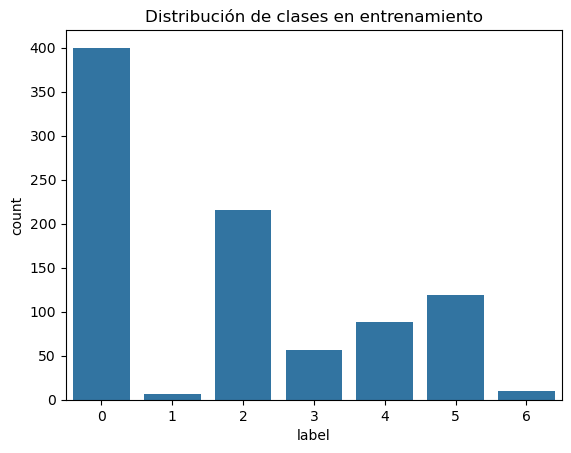

In [23]:
print(f"Total ejemplos: {len(df)}")
print(f"Clases únicas: {df['label'].unique()}")

sns.countplot(x=y_train)
plt.title("Distribución de clases en entrenamiento")
plt.show()

In [24]:
# Celda 5: Definición de funciones
def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted', zero_division=0),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall': recall_score(labels, preds, average='weighted', zero_division=0)
    }

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

In [25]:
# Celda 6: Entrenamiento del modelo
print(f"\n🚀 Iniciando entrenamiento del modelo: {model_name}")

# Cargar tokenizer y modelo
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Tokenizar datasets
train_tokenized = train_dataset.map(tokenize, batched=True)
test_tokenized = test_dataset.map(tokenize, batched=True)

# Determinar el número de clases
num_labels = len(df["label"].unique())
print(f"Número de clases detectadas: {num_labels}")

# Cargar modelo
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

# Configurar argumentos de entrenamiento
output_dir = f"./results/{model_name.replace('/', '_')}_{dataset_type}"
training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=learning_rate,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=epochs,
    weight_decay=weight_decay,
    warmup_ratio=warmup_ratio,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    seed=seed
)

# Crear trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

# Entrenar modelo
print("⏳ Entrenando modelo...")
trainer.train()


🚀 Iniciando entrenamiento del modelo: bert-base-multilingual-cased


Map: 100%|██████████| 224/224 [00:00<00:00, 10654.01 examples/s]


Número de clases detectadas: 7


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⏳ Entrenando modelo...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.517600,1.430770,0.446429,0.275573,0.199298,0.446429
2,1.423200,1.353858,0.446429,0.353343,0.352232,0.446429
3,1.345200,1.289678,0.513393,0.417092,0.351562,0.513393
4,1.248000,1.256205,0.544643,0.467095,0.417970,0.544643


TrainOutput(global_step=224, training_loss=1.3588979840278625, metrics={'train_runtime': 103.1391, 'train_samples_per_second': 34.71, 'train_steps_per_second': 2.172, 'total_flos': 235494966144000.0, 'train_loss': 1.3588979840278625, 'epoch': 4.0})

In [26]:
# Celda 7: Evaluación y resultados
print("\n📊 Evaluando modelo...")
metrics = trainer.evaluate()

print(f"\n🏆 Resultados finales:")
print(f"Accuracy: {metrics['eval_accuracy']:.4f}")
print(f"F1-Score: {metrics['eval_f1']:.4f}")
print(f"Precision: {metrics['eval_precision']:.4f}")
print(f"Recall: {metrics['eval_recall']:.4f}")

# Crear resumen de resultados
resultado_final = {
    "modelo": model_name,
    "dataset": dataset_type,
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "weight_decay": weight_decay,
    "warmup_ratio": warmup_ratio,
    "accuracy": metrics['eval_accuracy'],
    "f1": metrics['eval_f1'],
    "precision": metrics['eval_precision'],
    "recall": metrics['eval_recall'],
    "seed": seed
}

print(f"\n📋 Configuración utilizada:")
for key, value in resultado_final.items():
    print(f"{key}: {value}")


📊 Evaluando modelo...



🏆 Resultados finales:
Accuracy: 0.5446
F1-Score: 0.4671
Precision: 0.4180
Recall: 0.5446

📋 Configuración utilizada:
modelo: bert-base-multilingual-cased
dataset: descripciones
learning_rate: 3e-05
batch_size: 16
epochs: 4
weight_decay: 0.01
warmup_ratio: 0.0
accuracy: 0.5446428571428571
f1: 0.46709497100122105
precision: 0.4179699032310973
recall: 0.5446428571428571
seed: 1669259328


In [27]:
# Celda 8: Guardar modelo y resultados
# Crear directorio de guardado
save_path = f"C:/Users/Usuario/Documents/Workspace/Mirage/models/Undersampling/{model_name.replace('/', '_')}_{dataset_type}_final"
os.makedirs(save_path, exist_ok=True)

# Guardar modelo y tokenizer
print(f"\n💾 Guardando modelo en: {save_path}")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Guardar configuración y resultados
config_path = os.path.join(save_path, "training_results.json")
with open(config_path, "w") as f:
    json.dump(resultado_final, f, indent=2)

print(f"✅ Modelo guardado exitosamente!")
print(f"📁 Ubicación: {save_path}")
print(f"📄 Resultados guardados en: {config_path}")

# Mostrar resumen final
print(f"\n🎯 RESUMEN FINAL:")
print(f"Modelo: {model_name}")
print(f"Dataset: {dataset_type}")
print(f"F1-Score: {metrics['eval_f1']:.4f}")
print(f"Accuracy: {metrics['eval_accuracy']:.4f}")


💾 Guardando modelo en: C:/Users/Usuario/Documents/Workspace/Mirage/models/Undersampling/bert-base-multilingual-cased_descripciones_final
✅ Modelo guardado exitosamente!
📁 Ubicación: C:/Users/Usuario/Documents/Workspace/Mirage/models/Undersampling/bert-base-multilingual-cased_descripciones_final
📄 Resultados guardados en: C:/Users/Usuario/Documents/Workspace/Mirage/models/Undersampling/bert-base-multilingual-cased_descripciones_final\training_results.json

🎯 RESUMEN FINAL:
Modelo: bert-base-multilingual-cased
Dataset: descripciones
F1-Score: 0.4671
Accuracy: 0.5446
